# Prototype clean gfw ais 

In [1]:
import pandas as pd
import os 

# Set

In [2]:
# To set
year = 2025

temporal_granularity = 'DAILY'
spatial_resolution= "HIGH" # LOW or MEDIUM or HIGH

#

inp_folder = 'data/raw/from_notebooks'
inp_name = f'ais_{spatial_resolution.lower()}_{temporal_granularity.lower()}_ts_{str(year)}.parquet'

# Import 

In [3]:
input = os.path.join(inp_folder, inp_name)
df = pd.read_parquet(input)

# Clean

In [4]:
df.head(2)

,date,detections,flag,gear_type,hours,vessel_ids,vessel_id,vessel_type,entry_timestamp,exit_timestamp,first_transmission_date,last_transmission_date,imo,mmsi,call_sign,dataset,report_dataset,ship_name,lat,lon
0,2025-09-24,None,ITA,TRAWLERS,1.013333,None,a225c492b-b7fa-2be7-3aa8-731392a208db,FISHING,2025-02-10 00:00:00+00:00,2025-12-30 05:00:00+00:00,2014-03-07 18:49:40+00:00,2026-06-07 23:59:55+00:00,,247030620,IIJU,public-global-vessel-identity:v4.0,public-global-fishing-effort:v4.0,MINEA,45.60,13.47
1,2025-01-08,None,SVN,TRAWLERS,0.998333,None,1bddad50e-ed44-30b3-c9ff-6825a785300c,FISHING,2025-01-02 07:00:00+00:00,2025-12-22 18:00:00+00:00,2015-11-17 09:17:14+00:00,2026-06-01 18:23:19+00:00,,278538000,S5K2117,public-global-vessel-identity:v4.0,public-global-fishing-effort:v4.0,ANDREA,45.57,13.59


In [5]:
cols_to_drop = [
    'detections',
    'vessel_ids',
    'entry_timestamp', 'exit_timestamp','last_transmission_date', 'first_transmission_date',
    'imo', 'call_sign',
    'dataset', 'report_dataset',
    'vessel_type',
    'vessel_id'
]

df = df.drop(columns=cols_to_drop)

In [6]:
df.head()

,date,flag,gear_type,hours,mmsi,ship_name,lat,lon
0,2025-09-24,ITA,TRAWLERS,1.013333,247030620,MINEA,45.60,13.47
1,2025-01-08,SVN,TRAWLERS,0.998333,278538000,ANDREA,45.57,13.59
2,2025-06-01,SVN,SET_GILLNETS,1.006944,278577000,66-IZ,45.62,13.61
3,2025-12-18,ITA,TRAWLERS,1.010000,247050940,RINA S.,45.63,13.61
4,2025-05-13,SVN,INCONCLUSIVE,0.092778,278525000,BELLA ISTRIANA,45.54,13.60


In [7]:
rename_dict = {
    'lat': 'latitude',
    'lon': 'longitude'
    }

df = df.rename(columns=rename_dict)

In [8]:
df.head()

,date,flag,gear_type,hours,mmsi,ship_name,latitude,longitude
0,2025-09-24,ITA,TRAWLERS,1.013333,247030620,MINEA,45.60,13.47
1,2025-01-08,SVN,TRAWLERS,0.998333,278538000,ANDREA,45.57,13.59
2,2025-06-01,SVN,SET_GILLNETS,1.006944,278577000,66-IZ,45.62,13.61
3,2025-12-18,ITA,TRAWLERS,1.010000,247050940,RINA S.,45.63,13.61
4,2025-05-13,SVN,INCONCLUSIVE,0.092778,278525000,BELLA ISTRIANA,45.54,13.60


In [9]:
# re order columns 
cols = [
    'date', 'latitude', 'longitude', 'gear_type', 'mmsi', 'ship_name',  'hours', 'flag'
]

df = df[cols]

In [10]:
df.head()

,date,latitude,longitude,gear_type,mmsi,ship_name,hours,flag
0,2025-09-24,45.60,13.47,TRAWLERS,247030620,MINEA,1.013333,ITA
1,2025-01-08,45.57,13.59,TRAWLERS,278538000,ANDREA,0.998333,SVN
2,2025-06-01,45.62,13.61,SET_GILLNETS,278577000,66-IZ,1.006944,SVN
3,2025-12-18,45.63,13.61,TRAWLERS,247050940,RINA S.,1.010000,ITA
4,2025-05-13,45.54,13.60,INCONCLUSIVE,278525000,BELLA ISTRIANA,0.092778,SVN


# Clean nation

In [11]:
import matplotlib.pyplot as plt
gulf_df = pd.read_csv('data/raw/ts_gulf_coords.csv')
unq_coords = df.drop_duplicates(subset=['latitude', 'longitude']).copy()

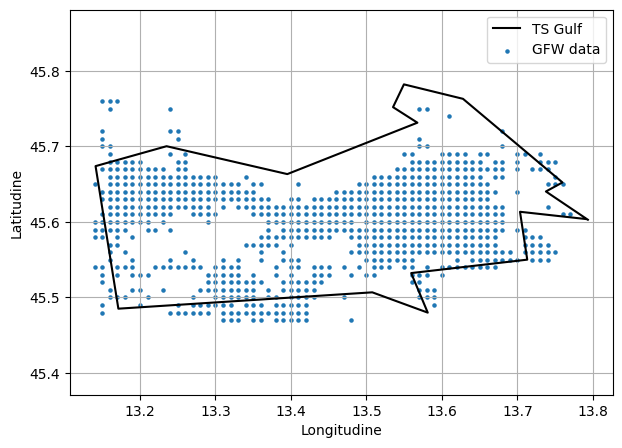

In [12]:
plt.figure(figsize=(7,5))

plt.plot(gulf_df['longitude'], gulf_df['latitude'], label = 'TS Gulf', color = 'black')
plt.scatter(unq_coords['longitude'], unq_coords['latitude'], label = 'GFW data', s = 5)
plt.xlim(13,14)
plt.ylim(45.3,45.9)
plt.xlabel("Longitudine")
plt.ylabel("Latitudine")
plt.grid(True)
plt.axis("equal")
plt.legend()

plt.show()

In [13]:
df = df [
    df['flag'] == 'ITA'
].copy()

In [14]:
ita_unq_coords = df.drop_duplicates(subset=['latitude', 'longitude']).copy()

In [15]:
#bound_lats = [45.60, 45.63, 45.57, 45.55, 45.45]
#bound_lons = [13.72,13.63,13.39, 13.31, 13.21]
#
#bounds_df = pd.DataFrame(
#    {
#        'latitude': bound_lats,
#        'longitude': bound_lons
#    }
#)
#
#bounds_df.to_csv('../data/raw/italy_marine_bounds.csv', index=False)

In [16]:
bounds_df = pd.read_csv('data/raw/italy_marine_bounds.csv')

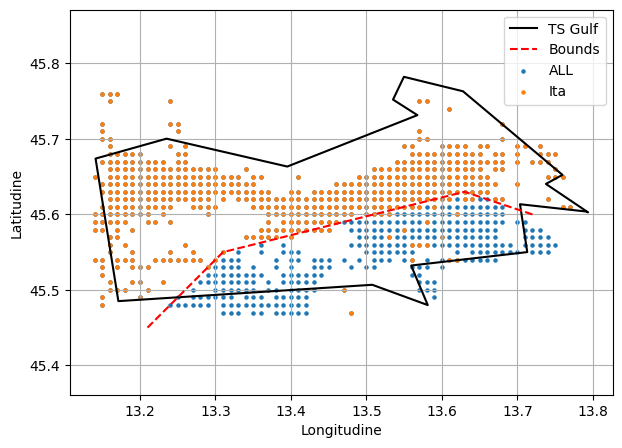

In [17]:
plt.figure(figsize=(7,5))

plt.plot(gulf_df['longitude'], gulf_df['latitude'], label = 'TS Gulf', color = 'black')
plt.plot(bounds_df['longitude'], bounds_df['latitude'], label = 'Bounds', color = 'red', linestyle='--')
plt.scatter(unq_coords['longitude'], unq_coords['latitude'], label = 'ALL', s = 5)
plt.scatter(ita_unq_coords['longitude'], ita_unq_coords['latitude'], label = 'Ita', s = 5)
plt.xlim(13,14)
plt.ylim(45.3,45.9)
plt.xlabel("Longitudine")
plt.ylabel("Latitudine")
plt.grid(True)
plt.axis("equal")
plt.legend()

plt.show()

In [18]:
import geopandas as gpd
from shapely.geometry import LineString, Point

def filter_above_boundary(df, bounds_df):
    # --- Boundary ---
    boundary_line = LineString(zip(bounds_df.longitude, bounds_df.latitude))

    # --- Ship points ---
    gdf = gpd.GeoDataFrame(
        df,
        geometry=[Point(xy) for xy in zip(df.longitude, df.latitude)]
    )

    def is_above_line(point, line):
        projection = line.interpolate(line.project(point))
        return point.y > projection.y

    gdf["above"] = gdf.geometry.apply(lambda p: is_above_line(p, boundary_line))

    filtered = gdf[gdf["above"]]
    
    return filtered.drop(columns=['geometry', 'above'])


In [19]:
filtered = filter_above_boundary(df, bounds_df)

In [20]:
fil_unq_coords = filtered.drop_duplicates(subset=['latitude', 'longitude']).copy()

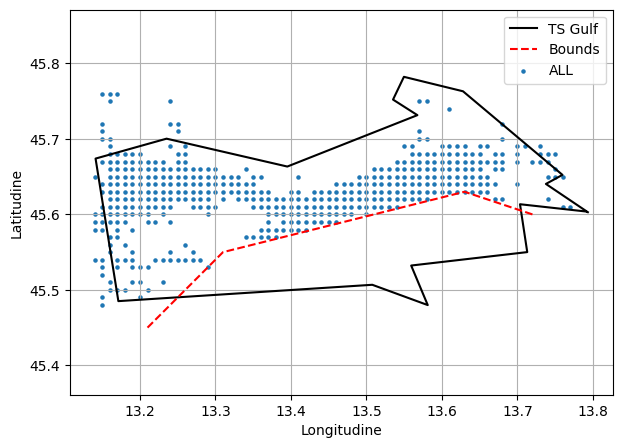

In [21]:
plt.figure(figsize=(7,5))

plt.plot(gulf_df['longitude'], gulf_df['latitude'], label = 'TS Gulf', color = 'black')
plt.plot(bounds_df['longitude'], bounds_df['latitude'], label = 'Bounds', color = 'red', linestyle='--')
plt.scatter(fil_unq_coords['longitude'], fil_unq_coords['latitude'], label = 'ALL', s = 5)
plt.xlim(13,14)
plt.ylim(45.3,45.9)
plt.xlabel("Longitudine")
plt.ylabel("Latitudine")
plt.grid(True)
plt.axis("equal")
plt.legend()

plt.show()

# Export

In [22]:
out_dir = 'data/interim/from_notebooks'
out_name = f'cleaned_{inp_name}'
out = os.path.join(out_dir, out_name)

filtered.to_parquet(out, index=False)